# Choice-length threshold ablation for MMLU-PT

**Research question.** How does a maximum threshold on the total number of words across all choices affect dataset retention and representation across exams and academic levels?

## Abstract

Very long answer choices can increase processing cost and may reveal extraction failures, but they can also be legitimate in legal, technical, and table-based questions. This notebook measures the total number of words across each question's four or five choices and evaluates maximum-length thresholds through distributional analysis, subgroup retention, and deterministic qualitative inspection. It also reports the incremental effect after the existing question-length filter. Without semantic quality labels or downstream evaluation, choice length alone cannot establish that removed records are invalid.

In [1]:
from __future__ import annotations

import hashlib
import platform
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from nemo_curator.stages.text.filters.heuristic import WordCountFilter

SEED = 42
MAX_THRESHOLDS = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 350, 400, 450, 500]
NEUTRAL_MAX = 1_000_000
SELECTED_MAX_CHOICES_WORDS = 300
QUESTION_MIN_WORDS = 4
QUESTION_MAX_WORDS = 1_000

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current directory.")

REPO_ROOT = find_repo_root(Path.cwd())
INPUT_DIR = REPO_ROOT / "output" / "03 - pre-word-filter"
print(f"Repository: {REPO_ROOT}")
print(f"Input: {INPUT_DIR}")
print(f"Python: {platform.python_version()}")

Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Input: /home/aluno_paulosantana/repositories/mmlu-pt/output/03 - pre-word-filter
Python: 3.12.3


## 1. Data and reproducibility

The input is the public-field projection produced after structural MCQA validation and before any length filtering. Files are sorted before loading and hashing. The SHA-256 fingerprint identifies the exact materialized snapshot analyzed below.

In [2]:
EXPECTED_COLUMNS = [
    "exam",
    "exam_edition",
    "exam_url",
    "num",
    "question",
    "choices",
    "answer",
    "academic_level",
]

input_files = sorted(INPUT_DIR.glob("*.jsonl"))
if not input_files:
    raise FileNotFoundError(
        f"No JSONL files found in {INPUT_DIR}. Run src/mmlu_pt/pipeline_minimal.py first."
    )

frames = []
for path in input_files:
    frame = pd.read_json(path, lines=True, convert_dates=False)
    frame["_partition_file"] = path.name
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if data.empty:
    raise ValueError("The pre-word-filter dataset is empty.")
if data["question"].isna().any():
    raise ValueError("The question field contains null values.")

def has_valid_choices(value: object) -> bool:
    return (
        isinstance(value, list)
        and len(value) in {4, 5}
        and all(isinstance(choice, str) and bool(choice.strip()) for choice in value)
    )

invalid_choices = ~data["choices"].map(has_valid_choices)
if invalid_choices.any():
    raise ValueError(f"Found {int(invalid_choices.sum()):,} records with invalid choices.")

digest = hashlib.sha256()
for path in input_files:
    digest.update(path.name.encode("utf-8"))
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)

snapshot = pd.Series(
    {
        "files": len(input_files),
        "records": len(data),
        "exams": data["exam"].nunique(),
        "exam_editions": data["exam_edition"].nunique(dropna=True),
        "academic_levels": data["academic_level"].nunique(),
        "four_choice_records": int((data["choices"].map(len) == 4).sum()),
        "five_choice_records": int((data["choices"].map(len) == 5).sum()),
        "sha256": digest.hexdigest(),
    },
    name="value",
)
display(snapshot.to_frame())

,value
files,19
records,41988
exams,17
exam_editions,1045
academic_levels,2
four_choice_records,15309
five_choice_records,26679
sha256,2a7ded87ec71df2f3d304e392ea3c1525ba432bcd9d4566f6a82525bc3360caa


## 2. Measurement protocol

Each choice is measured separately with the exact NeMo Curator implementation used by the pipeline, then the counts are summed. For Portuguese, version 1.3.0 strips leading and trailing whitespace and splits on whitespace. A record is retained when the total is less than or equal to the maximum threshold. The largest individual choice and its share of the total are retained as diagnostics, but they do not determine filtering.

In [3]:
word_counter = WordCountFilter(min_words=0, max_words=NEUTRAL_MAX, lang="pt")

data["choice_word_counts"] = data["choices"].map(
    lambda choices: [int(word_counter.score_document(choice)) for choice in choices]
)
data["choices_word_count"] = data["choice_word_counts"].map(sum).astype(int)
data["max_choice_word_count"] = data["choice_word_counts"].map(max).astype(int)
data["max_choice_share"] = data["max_choice_word_count"] / data["choices_word_count"]
data["choice_count"] = data["choices"].map(len).astype(int)
data["question_word_count"] = data["question"].map(word_counter.score_document).astype(int)

neutral_mask = data["choices_word_count"] <= NEUTRAL_MAX
assert neutral_mask.all(), "The configured neutral threshold unexpectedly removes records."

question_filter_mask = data["question_word_count"].between(
    QUESTION_MIN_WORDS,
    QUESTION_MAX_WORDS,
    inclusive="both",
)

percentiles = [0.001, 0.005, 0.01, 0.025, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 0.999]
overall = data[
    ["choices_word_count", "max_choice_word_count", "max_choice_share"]
].describe(percentiles=percentiles).T
display(overall)

,count,mean,std,min,0.1%,0.5%,1%,2.5%,5%,10%,25%,50%,75%,90%,95%,97.5%,99%,99.5%,99.9%,max
choices_word_count,"41,988.000",52.758,45.560,4.000,4.000,4.000,4.000,5.000,5.000,8.000,16.000,40.000,77.000,114.000,138.000,163.000,196.000,225.065,297.078,595.000
max_choice_word_count,"41,988.000",15.030,14.102,1.000,1.000,1.000,1.000,1.000,1.000,2.000,4.000,11.000,22.000,33.300,41.000,48.000,58.000,67.065,104.013,343.000
max_choice_share,"41,988.000",0.274,0.067,0.200,0.200,0.200,0.200,0.200,0.200,0.200,0.230,0.254,0.308,0.360,0.400,0.438,0.500,0.542,0.714,0.972


In [4]:
level_summary = (
    data.groupby("academic_level")["choices_word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), maximum="max")
    .sort_values("records", ascending=False)
)
exam_summary = (
    data.groupby("exam")["choices_word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), q99=lambda s: s.quantile(0.99), maximum="max")
    .sort_values("records", ascending=False)
)
choice_count_summary = (
    data.groupby("choice_count")["choices_word_count"]
    .agg(records="size", mean="mean", median="median", q95=lambda s: s.quantile(0.95), maximum="max")
)
display(
    Markdown("### Academic level"), level_summary,
    Markdown("### Exam"), exam_summary,
    Markdown("### Number of choices"), choice_count_summary,
)

### Academic level

,records,mean,median,q95,maximum
academic_level,,,,,
undergraduate,31996,58.081,48.000,146.000,595
high_school,9992,35.713,25.000,105.000,446


### Exam

,records,mean,median,q95,q99,maximum
exam,,,,,,
ENADE,10793,50.874,25.000,145.000,209.000,595
OAB,10331,73.050,71.000,146.000,195.000,528
BNDES,4075,44.319,32.000,129.000,180.000,338
ENEM,2689,35.174,28.000,94.000,136.000,342
OBI,2301,22.208,20.000,52.000,75.000,135
FUVEST,1662,42.593,27.500,118.950,160.000,215
RESIDENCIA_USP_UNICAMP,1575,43.274,32.000,115.000,168.000,429
POSCOMP,1311,41.098,30.000,115.000,172.000,337
REVALIDA,1195,50.792,41.000,130.300,180.000,249


### Number of choices

,records,mean,median,q95,maximum
choice_count,,,,,
4,15309,65.611,61.000,144.000,528
5,26679,45.383,28.000,135.000,595


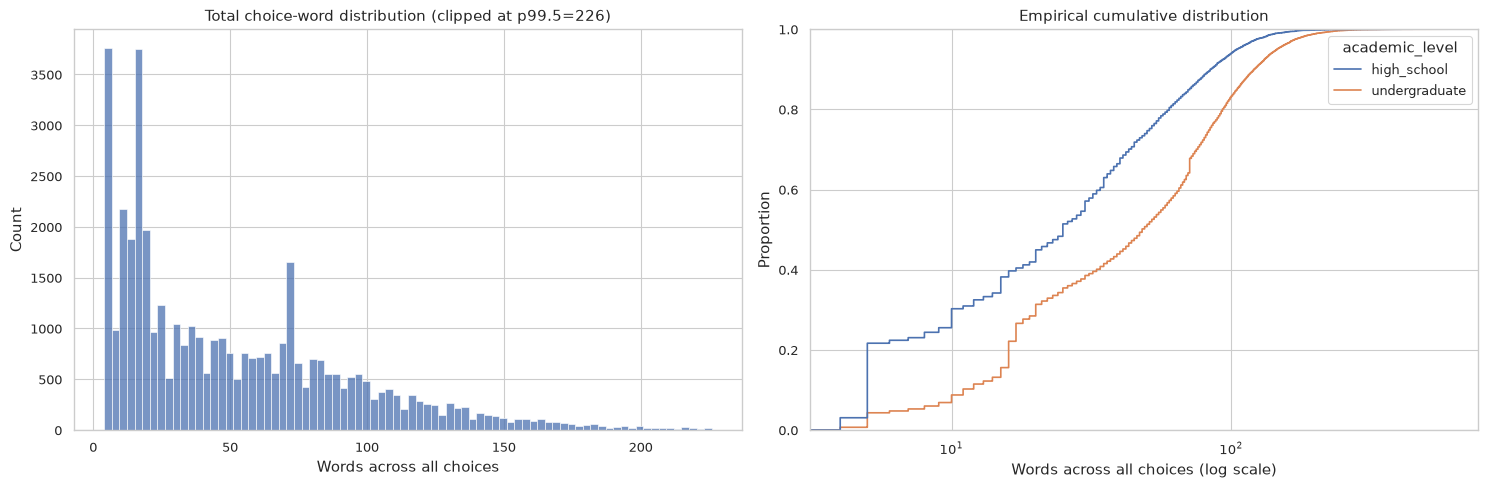

In [5]:
q995 = int(np.ceil(data["choices_word_count"].quantile(0.995)))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(
    data=data[data["choices_word_count"] <= q995],
    x="choices_word_count",
    bins=80,
    ax=axes[0],
)
axes[0].set(
    title=f"Total choice-word distribution (clipped at p99.5={q995})",
    xlabel="Words across all choices",
)
sns.ecdfplot(data=data, x="choices_word_count", hue="academic_level", ax=axes[1])
axes[1].set(
    xscale="log",
    title="Empirical cumulative distribution",
    xlabel="Words across all choices (log scale)",
)
plt.tight_layout()
plt.show()

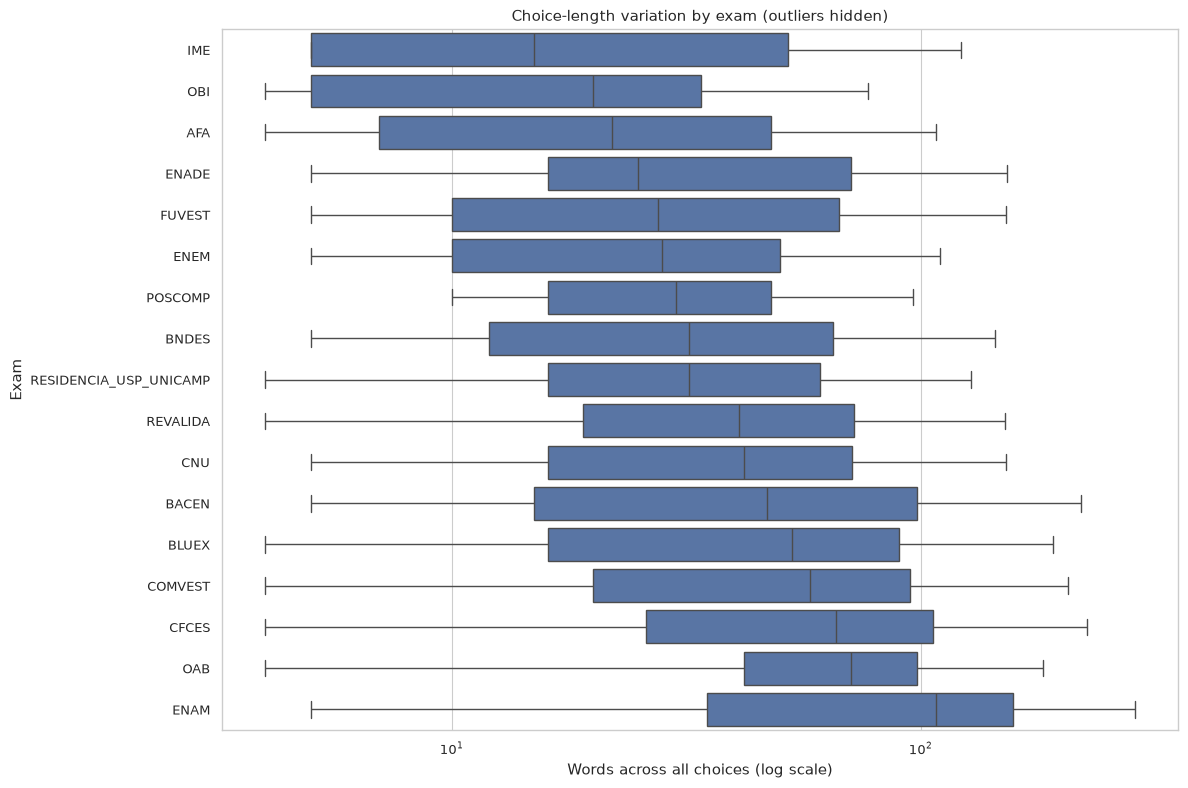

In [6]:
exam_order = exam_summary.sort_values("median").index
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=data,
    y="exam",
    x="choices_word_count",
    order=exam_order,
    showfliers=False,
    color="#4C72B0",
)
plt.xscale("log")
plt.title("Choice-length variation by exam (outliers hidden)")
plt.xlabel("Words across all choices (log scale)")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 3. Tail inspection

Large totals are not automatically errors. The table below retains identifying metadata, individual choice counts, and normalized previews so that extraction failures, tables, enumerated legal propositions, and legitimate long alternatives can be distinguished manually.

In [7]:
def normalize_preview(text: str, max_chars: int) -> str:
    return re.sub(r"\s+", " ", text).strip()[:max_chars]

def format_choices_preview(choices: list[str], max_chars: int = 140) -> str:
    return " | ".join(
        f"{index + 1}. {normalize_preview(choice, max_chars)}"
        for index, choice in enumerate(choices)
    )

def preview_table(frame: pd.DataFrame, limit: int | None = None) -> pd.DataFrame:
    columns = [
        "exam",
        "exam_edition",
        "num",
        "academic_level",
        "choices_word_count",
        "max_choice_word_count",
        "max_choice_share",
        "choice_word_counts",
        "question",
        "choices",
    ]
    result = frame[columns].copy()
    result["question"] = result["question"].map(lambda text: normalize_preview(text, 180))
    result["choices"] = result["choices"].map(format_choices_preview)
    return result.head(limit) if limit is not None else result

longest = data.sort_values(
    ["choices_word_count", "max_choice_word_count", "exam"],
    ascending=[False, False, True],
)
display(Markdown("### Twenty largest choice totals"), preview_table(longest, 20))

### Twenty largest choice totals

,exam,exam_edition,num,academic_level,choices_word_count,max_choice_word_count,max_choice_share,choice_word_counts,question,choices
16967,ENADE,ENADE 2017 - sistema_de_informacao,20,undergraduate,595,119,0.200,"[119, 119, 119, 119, 119]","Em uma seleção para uma vaga de programador, o setor de recursos humanos de uma empresa criou três sentenças essenciais para a escolha do candidato, representadas pelas variáve...",1. | P | q | r | (p$\lor$q) | (q$\land eg$r) | S | |---|---|---|---|---|---| | V | V | V | V | V | V | | V | V | F | V | V | V | | V | F | V | | 2. | p | q | r | (p$\lor$q) | ...
32179,OAB,OAB-DF 2003.3,23,undergraduate,528,263,0.498,"[113, 121, 31, 263]",Qual a alínea em que se identifica uma premissa errônea?,"1. Reputa-se fundada a suspeição de parcialidade do juiz, quando: I. amigo íntimo ou inimigo capital de qualquer das partes; II. alguma das par | 2. valor da causa constará sem..."
35967,COMVEST,COMVEST 2016,79,high_school,446,343,0.769,"[343, 38, 34, 31]","A publicidade acima foi divulgada no site da agência FAMIGLIA no dia 24 de janeiro de 2007, véspera do aniversário de São Paulo, no período em que foi proposta","1. a aprendizagem. É uma construção coletiva”, explica. O educador diz que a roda constrói consensos. “Porque todo processo eletivo é um proces | 2. b) O texto escrito em letra..."
21702,RESIDENCIA_USP_UNICAMP,Residência Médica USP - Psiquiatria Forense - 2024,29,undergraduate,429,123,0.287,"[106, 79, 123, 121]",Trata-se de internação voluntária:,"1. Juliana, uma mulher de 38 anos de idade, foi trazida ao pronto-socorro por sua irmã, Ana. Ana relata que Juliana tem um histórico de transto | 2. Pedro, um homem de 42 anos ..."
17081,ENADE,ENADE 2018 - administracao,13,undergraduate,407,87,0.214,"[72, 84, 79, 85, 87]","Segundo dados do Censo da Educação Superior, observa-se, nos últimos anos, um aumento do número de Instituições de Educação Superior privadas no Brasil. Nessa nova realidade, o...",1. | | Processos internos | Clientes | Econômico-financeira | |---|---|---|---| | Estratégia | Otimizar a utilização da capacidade instalada | | 2. | | Processos internos | Cl...
35802,COMVEST,COMVEST 2015,4,high_school,406,230,0.567,"[230, 19, 21, 136]",O cartaz a seguir foi usado em uma campanha pública para doação de sangue. (Disponível em www.facebook.com/pages/HEMORIO/144978045 579742?fref=ts. Acessado em 08/09/2014.) Glos...,"1. a geomicrobióloga Penelope Boston caminha por uma água turva que bate em seus tornozelos, em uma gruta, cerca de 15 metros abaixo da superfí | 2. b) A expressão “rolezinho” ..."
33362,CFCES,8º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),34,undergraduate,392,145,0.370,"[57, 84, 145, 106]","As condições abaixo devem ser verificadas para reconhecimento de receita, conforme previsto nas Normas Brasileiras de Contabilidade e mais especificamente nas orientações sobre...","1. Equipamento, caracterizado como bem de capital, vendido, recebido e despachado ao cliente na data de encerramento das demonstrações contábei | 2. Venda de parte de um imóvel..."
33308,CFCES,6º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),29,undergraduate,392,122,0.311,"[122, 84, 110, 76]","Indique a alternativa **incorreta**, segundo as Normas Brasileiras de Contabilidade:","1. Um auditor independente (Al 1), atuando como especialista, efetuou avaliações a valor de mercado/valor econômico de acervo patrimonial de su | 2. Entre outros, os serviços d..."
22118,ENAM,1° Edição 2024 reaplicação,30,undergraduate,388,92,0.237,"[79, 92, 76, 58, 83]","Em julgamento emblemático, o Supremo Tribunal Federal reconheceu que os integrantes do grupo LGBTI+, como qualquer outra pessoa, nascem iguais em dignidade e direitos e possuem...","1. a existência de omissão normativa inconstitucional do Poder Legislativo da União foi declarada, para fins de cientificar o Congresso Naciona | 2. até que sobrevenha lei eman..."
4017,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,1,undergr

## 4. Maximum-threshold ablation

For each inclusive maximum, we report overall retention, academic-level retention, the least-retained exam, and the maximum absolute change in exam prevalence. We also report how many additional records the choice threshold removes after applying the pipeline's current 4–1,000 word question filter.

In [8]:
baseline_exam_share = data["exam"].value_counts(normalize=True)
baseline_exam_size = data["exam"].value_counts()
baseline_level_size = data["academic_level"].value_counts()

def threshold_metrics(max_choices_words: int) -> dict[str, float | int | str]:
    choice_mask = data["choices_word_count"] <= max_choices_words
    retained = data.loc[choice_mask]
    exam_retention = (
        retained["exam"].value_counts().reindex(baseline_exam_size.index, fill_value=0)
        / baseline_exam_size
    )
    retained_exam_share = (
        retained["exam"].value_counts(normalize=True).reindex(baseline_exam_share.index, fill_value=0)
    )
    level_retention = (
        retained["academic_level"].value_counts().reindex(baseline_level_size.index, fill_value=0)
        / baseline_level_size
    )
    combined_mask = choice_mask & question_filter_mask
    return {
        "max_choices_words": max_choices_words,
        "retained": int(choice_mask.sum()),
        "removed": int((~choice_mask).sum()),
        "retention_pct": 100 * choice_mask.mean(),
        "high_school_retention_pct": 100 * level_retention.get("high_school", np.nan),
        "undergraduate_retention_pct": 100 * level_retention.get("undergraduate", np.nan),
        "worst_exam_retention_pct": 100 * exam_retention.min(),
        "worst_exam": str(exam_retention.idxmin()),
        "max_exam_share_shift_pp": 100 * (retained_exam_share - baseline_exam_share).abs().max(),
        "incremental_removed_after_question_filter": int((~choice_mask & question_filter_mask).sum()),
        "overlap_with_question_filter_removals": int((~choice_mask & ~question_filter_mask).sum()),
        "combined_retained": int(combined_mask.sum()),
        "combined_retention_pct": 100 * combined_mask.mean(),
    }

maximum_ablation = pd.DataFrame(threshold_metrics(maximum) for maximum in MAX_THRESHOLDS)
neutral_metrics = pd.DataFrame([threshold_metrics(NEUTRAL_MAX)])
display(
    Markdown("### Maximum-threshold ablation"), maximum_ablation,
    Markdown("### Neutral choice threshold"), neutral_metrics,
)

### Maximum-threshold ablation

,max_choices_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp,incremental_removed_after_question_filter,overlap_with_question_filter_removals,combined_retained,combined_retention_pct
0,25,16478,25510,39.245,51.421,35.442,14.452,OAB,15.544,25325,185,16406,39.073
1,50,23882,18106,56.878,74.680,51.319,29.524,ENAM,10.887,17976,130,23755,56.576
2,75,31087,10901,74.038,86.789,70.056,35.873,ENAM,6.571,10817,84,30914,73.626
3,100,36062,5926,85.886,94.085,83.326,45.714,ENAM,2.562,5889,37,35842,85.362
4,125,38911,3077,92.672,97.658,91.115,57.143,ENAM,0.784,3063,14,38668,92.093
5,150,40483,1505,96.416,99.079,95.584,70.476,ENAM,0.216,1496,9,40235,95.825
6,175,41260,728,98.266,99.650,97.834,82.857,ENAM,0.118,725,3,41006,97.661
7,200,41603,385,99.083,99.770,98.869,91.429,ENAM,0.087,382,3,41349,98.478
8,225,41778,210,99.500,99.900,99.375,94.921,ENAM,0.063,209,1,41522,98.890
9,250,41873,115,99.726,99.920,99.666,96.814,CFCES,0.050,114,1,41617,99.116


### Neutral choice threshold

,max_choices_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp,incremental_removed_after_question_filter,overlap_with_question_filter_removals,combined_retained,combined_retention_pct
0,1000000,41988,0,100.000,100.000,100.000,100.000,ENADE,0.000,0,0,41731,99.388


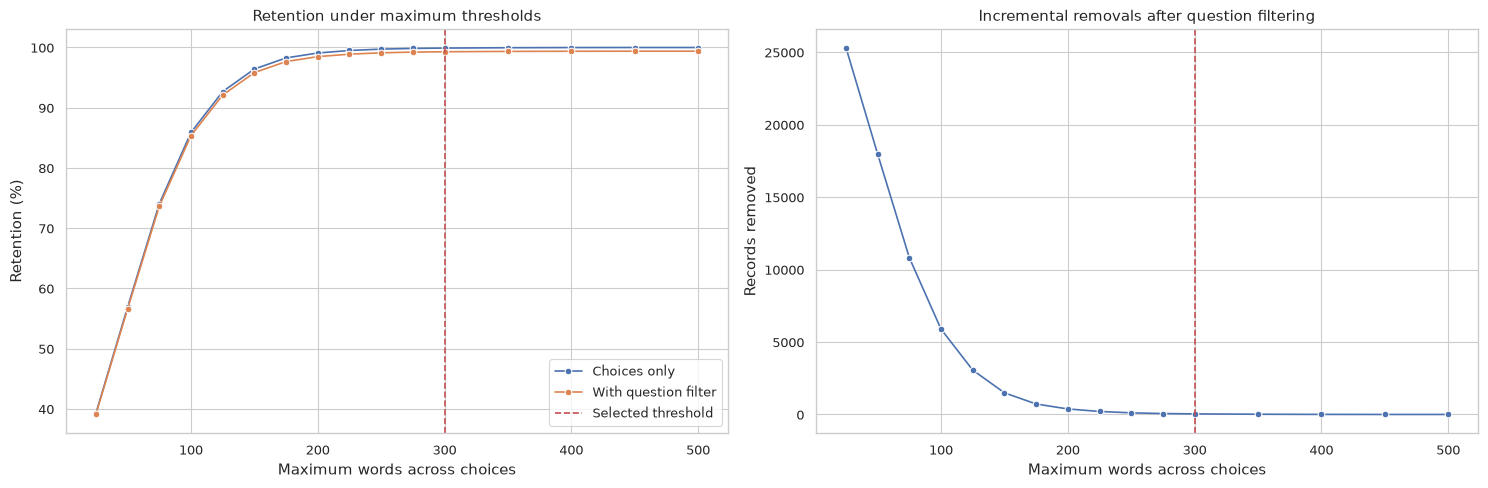

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=maximum_ablation, x="max_choices_words", y="retention_pct", marker="o", ax=axes[0], label="Choices only")
sns.lineplot(data=maximum_ablation, x="max_choices_words", y="combined_retention_pct", marker="o", ax=axes[0], label="With question filter")
axes[0].axvline(SELECTED_MAX_CHOICES_WORDS, color="#C44E52", linestyle="--", label="Selected threshold")
axes[0].set(title="Retention under maximum thresholds", xlabel="Maximum words across choices", ylabel="Retention (%)")
axes[0].legend()

sns.lineplot(data=maximum_ablation, x="max_choices_words", y="incremental_removed_after_question_filter", marker="o", ax=axes[1])
axes[1].axvline(SELECTED_MAX_CHOICES_WORDS, color="#C44E52", linestyle="--")
axes[1].set(title="Incremental removals after question filtering", xlabel="Maximum words across choices", ylabel="Records removed")
plt.tight_layout()
plt.show()

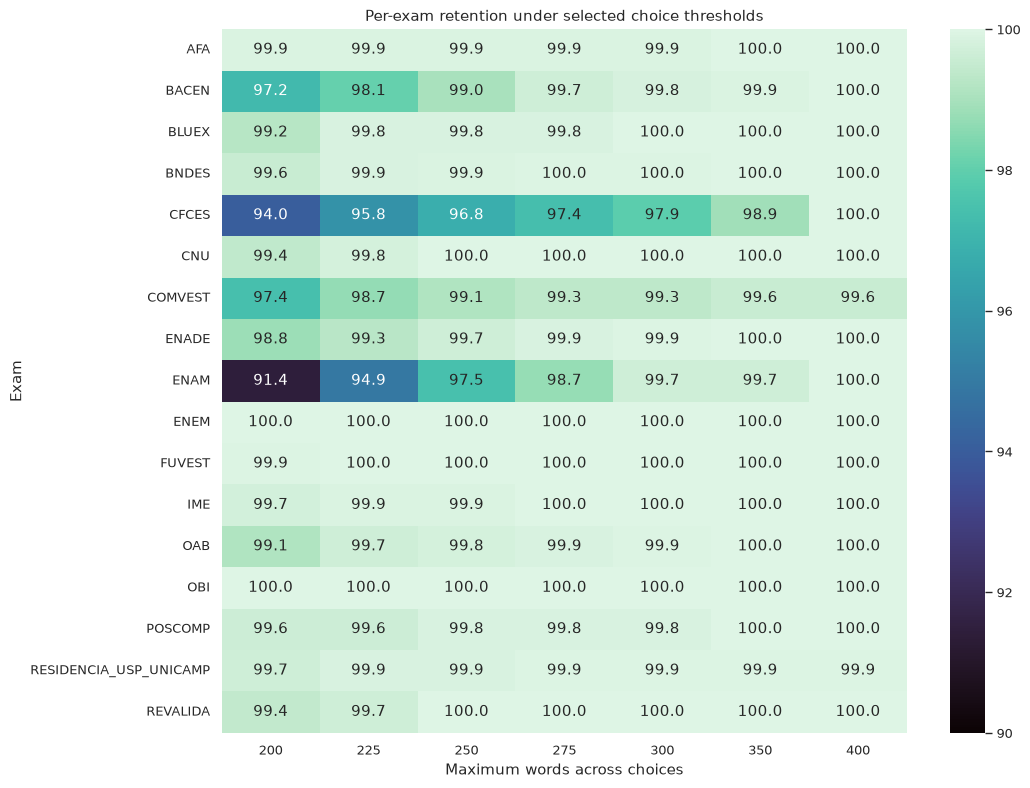

In [10]:
selected_thresholds = [200, 225, 250, 275, 300, 350, 400]
exam_retention = pd.DataFrame(
    {
        maximum: (
            data.loc[data["choices_word_count"] <= maximum, "exam"]
            .value_counts()
            .reindex(baseline_exam_size.index, fill_value=0)
            / baseline_exam_size
            * 100
        )
        for maximum in selected_thresholds
    }
).sort_index()

plt.figure(figsize=(11, 8))
sns.heatmap(exam_retention, annot=True, fmt=".1f", cmap="mako", vmin=90, vmax=100)
plt.title("Per-exam retention under selected choice thresholds")
plt.xlabel("Maximum words across choices")
plt.ylabel("Exam")
plt.tight_layout()
plt.show()

## 5. Deterministic boundary audit

The following samples are deterministic and stratified around the candidate thresholds. They support manual assessment of whether large totals arise from malformed extraction, repeated tables, verbose but valid alternatives, or legitimate domain-specific material.

In [11]:
def deterministic_sample(frame: pd.DataFrame, n: int = 8) -> pd.DataFrame:
    if frame.empty:
        return preview_table(frame)
    sampled = frame.sample(n=min(n, len(frame)), random_state=SEED)
    return preview_table(sampled.sort_values(["choices_word_count", "exam"]))

boundary_bands = {
    "201–250 words": data[data["choices_word_count"].between(201, 250)],
    "251–300 words": data[data["choices_word_count"].between(251, 300)],
    "301–350 words": data[data["choices_word_count"].between(301, 350)],
    "More than 350 words": data[data["choices_word_count"] > 350],
}
for label, frame in boundary_bands.items():
    display(Markdown(f"### {label}: {len(frame):,} records"), deterministic_sample(frame))

### 201–250 words: 270 records

,exam,exam_edition,num,academic_level,choices_word_count,max_choice_word_count,max_choice_share,choice_word_counts,question,choices
14029,ENADE,ENADE 2013 - tecnologia_em_gestao_ambiental,12,undergraduate,201,44,0.219,"[41, 33, 44, 42, 41]","O Programa Nacional de Educação Ambiental, publicado em 2005 pelo Ministério do Meio Ambiente, propõe que a prática de Educação Ambiental deve ir além da disponibilização de in...","1. O foco das propostas de Educação Ambiental para os pescadores enfatizará os estudos da ictiofauna local, tais como dourada, pirarucu e piram | 2. O foco das propostas de Edu..."
30453,OAB,OAB-DF 2006.3,35,undergraduate,202,66,0.327,"[30, 41, 66, 65]","Sobre o crime continuado, assinale a alternativa CORRETA:","1. ocorre quando o agente, mediante mais de uma ação ou omissão, pratica dois ou mais crimes, idênticos ou não, aplicam-se cumulativamente s pe | 2. ocorre quando o agente, med..."
10561,ENADE,ENADE 2006 - direito,31,undergraduate,205,61,0.298,"[40, 39, 26, 39, 61]","A princípio, a marca tinha a função restrita de indicar a origem ou procedência da mercadoria, atingindo apenas a indústria. Posteriormente se estendeu ao comércio e, mais rece...","1. goza de proteção legal, seu objeto entra na classificação dos bens, sendo suscetível de cessão, e que comete crime quem reproduz, sem autori | 2. goza de proteção legal, seu..."
20151,ENADE,ENADE 2023 - medicina_veterinaria,20,undergraduate,212,56,0.264,"[33, 41, 41, 41, 56]","Uma cadela de 7 anos de idade, sem raça definida (SRD), com peso de 32 kg, é levada para atendimento emergencial em um hospital veterinário às 22h. A paciente estava em trabalh...","1. O uso de xilazina, um agente alfa-2-adrenérgico, como medicação pré-anestésica de cadelas gestantes é a escolha mais indicada, pois esse fár | 2. O uso de opioides, como but..."
19230,ENADE,ENADE 2022 - direito,12,undergraduate,220,66,0.300,"[33, 34, 41, 46, 66]","A nova Lei de Licitações (Lei n. 14.133/2021) estabelece diversas mudanças no processo licitatório, tornando a compra ou a contratação de bens e serviços mais rápida e eficient...",1. A aplicação da modalidade de diálogo competitivo da Administração Pública com as empresas licitantes daria causa a subjetivismos e a tratame | 2. A adoção da modalidade de d...
5336,BNDES,BNDES 2005 - Contador,60,undergraduate,222,57,0.257,"[47, 22, 57, 53, 43]",Segundo a Resolução 3.198 é legítimo afirmar:,1. é vedada a contratação e a manutenção de auditor independente caso fique configurado o pagamento de honorários e reembolso de despesas deste | 2. as organizações auditadas d...
18072,ENADE,ENADE 2019 - medicina,18,undergraduate,244,55,0.225,"[42, 51, 55, 53, 43]","Uma mulher de 27 anos de idade, babá de 2 crianças pequenas, é levada pelo pai ao médico de família. Na consulta, relata que se encontra com humor deprimido, perda de prazer em...",1. Iniciar uso de cloridrato de fluoxetina 20 mg ao dia; afastar a paciente de suas atividades laborativas; realizar contrato de não suicídio; | 2. Iniciar uso de cloridrato d...
30932,OAB,OAB-BR 2006.1,30,undergraduate,245,111,0.453,"[36, 52, 111, 46]","A respeito dos alimentos e da ação de alimentos, assinale a opção correta.",1. A execução de alimentos pelo rito da coerção pessoal tem como pressuposto a atualidade do débito referente às três últimas parcelas anterior | 2. A sentença que fixa os alim...


### 251–300 words: 73 records

,exam,exam_edition,num,academic_level,choices_word_count,max_choice_word_count,max_choice_share,choice_word_counts,question,choices
4274,BACEN,Procurador - Conhecimentos Específicos - 2002,54,undergraduate,251,68,0.271,"[44, 68, 54, 23, 62]","Com referência à Ação Rescisória, tem-se como certo que:","1. atualmente, por expressa disposição legal em vigor, pode o tribunal, a qualquer tempo, conceder medida cautelar para suspender os efeitos da | 2. segundo entendimento atual ..."
35926,COMVEST,COMVEST 2016,38,high_school,259,179,0.691,"[23, 26, 31, 179]","If apes go extinct, so could entire forests Bonobos eat a lot of fruit, and fruit contains seeds. Those seeds travel through a bonobo’s digestive system while bonobo itself tra...","1. a) Os bonobos se alimentam de plantas e suas fezes ajudam a adubar florestas. Como andam grandes distâncias, espalham esse adubo pela flores | 2. b) Os bonobos vivem em árvo..."
3893,BACEN,Analista de Finanças - Conhecimentos Gerais - 2006,29,undergraduate,261,68,0.261,"[39, 53, 56, 45, 68]",A economia brasileira passou por diversos planos de crescimento e de estabilização ao longo das últimas quatro décadas. É correto afirmar que:,1. o II Plano Nacional de Desenvolvimento Econômico representou uma opção pela continuidade do crescimento econômico em face da crise do petról | 2. a política de ajustamento e...
15333,ENADE,ENADE 2015 - tecnologia_em_gastronomia,23,undergraduate,266,69,0.259,"[46, 51, 50, 50, 69]","Em outubro de 2010, foi criado o documento denominado **A Carta de São Paulo: por uma cozinha sustentável**, que integra uma campanha dos profissionais de cozinha, com o princi...","1. a ecogastronomia, que estimula a conexão com o campo, com os pequenos produtores, com as matérias-primas mais diversas e tradicionais, com c | 2. a cozinha tecnoemocional, c..."
18718,ENADE,ENADE 2021 - geografia_licenciatura,27,undergraduate,275,58,0.211,"[58, 57, 58, 49, 53]",Entre as ações docentes centradas na construção de conceitos pelos alunos encontra-se a de se considerar a vivência como parâmetro do processo de conhecimento. É do confronto d...,"1. solicitar que cada aluno desenhe a noção que tem de paisagem e, em seguida, identifique alguma figura do livro didático que tenha relação co | 2. apresentar, por imagens, di..."
32369,OAB,OAB-DF 2003.1,23,undergraduate,278,104,0.374,"[43, 104, 74, 57]",Registre a questão errada:,"1. Cabem embargos infringentes quando o acórdão não unânime houver reformado, em grau de apelação ou de agravo de instrumento, a sentença de mé | 2. O recurso extraordinário e ..."
10761,ENADE,ENADE 2007 - enfermagem,31,undergraduate,286,65,0.227,"[56, 52, 55, 65, 58]","Antonio de Pádua, 25 anos de idade, foi levado à Unidade Básica de Saúde por um colega. Antonio trabalha há 90 dias em uma construção civil, apresenta-se hoje com febre e exant...","1. Justificativa: A maioria dos casos de rubéola são subclínicos, portanto, é pouco importante a busca de fonte de infecção e a observação dos | 2. Justificativa: A articulaçã..."
633,BLUEX,USP_2024,10,high_school,292,250,0.856,"[10, 11, 12, 9, 250]",Por quê? Porque pensar em direitos humanos tem um pressuposto: reconhecer que aquilo que consideramos indispensável para nós é também indispensável para o próximo. (...). Nesse...,"1. é privilégio de minorias, pois são bens que exigem reflexão. | 2. deve ser reivindicado como um direito, e não como um privilégio. | 3. vitimiza as pessoas que não têm acess..."


### 301–350 words: 25 records

,exam,exam_edition,num,academic_level,choices_word_count,max_choice_word_count,max_choice_share,choice_word_counts,question,choices
32182,OAB,OAB-DF 2003.3,26,undergraduate,309,146,0.472,"[68, 24, 146, 71]",Assinale a opção errada:,"1. A ação principal e a cautelar poderão ser propostas pelo Ministério Público, pela União, pelos Estados e Municípios. Poderão também ser prop | 2. Fazem coisa julgada: a) a v..."
32360,OAB,OAB-DF 2003.1,13,undergraduate,310,112,0.361,"[112, 27, 109, 62]",Destaque a opção totalmente correta:,"1. Consideram-se bens públicos: a) os de uso comum do povo, tais como rios, estradas, mares, ruas e praças; b) os de uso especial, tais como ed | 2. Configura-se a coação quand..."
33294,CFCES,6º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),15,undergraduate,314,111,0.354,"[25, 111, 96, 82]","Considere a situação hipotética a seguir. Um sócio responsável por avaliações de risco e de independência de uma empresa de auditoria nacional, com atuação nos principais estad...","1. Decidiu-se que o sócio de auditoria, ex-diretor da empresa a ser auditada cujo relacionamento foi descontinuado em dezembro/2006, não deveri | 2. A orientação do sócio respo..."
32183,OAB,OAB-DF 2003.3,27,undergraduate,322,157,0.488,"[26, 29, 110, 157]",Escolha a opção incorreta:,"1. recurso extraordinário, ou o recurso especial, pelas respectivas naturezas jurídicas não podem ser interpostos contra decisão interlocutória | 2. relator negará seguimento a..."
4018,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,2,undergraduate,326,78,0.239,"[61, 64, 67, 56, 78]",Em relação aos sistemas de arquivos é correto afirmar:,"1. FAT32 e NTFS possuem suas características, vantagens e desvantagens, não sendo compatíveis, entretanto, com todos os sistemas operacionais: | 2. O tamanho máximo de uma par..."
37225,POSCOMP,POSCOMP_2002,48,undergraduate,326,81,0.248,"[79, 81, 80, 81, 5]",48. Marque a alternativa onde todos os conceitos estão corretos.,"1. a) Em um diagrama de fluxo de dados, uma entidade externa representa um produtor ou um consumidor de informação e está fora dos limites do s | 2. b) Em um diagrama de fluxo ..."
32705,CFCES,10º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),49,undergraduate,330,111,0.336,"[63, 111, 91, 65]","De acordo com a NBC Т 10.2 – Operações de Arrendamento Mercantil, assinale a opção que apresenta uma informação **NÃO** condizente com as regras de mensuração subsequente de ar...",1. Os pagamentos mínimos do arrendamento mercantil devem ser segregados entre encargo financeiro e redução do passivo em aberto. O encargo fina | 2. Um arrendamento mercantil f...
4646,BNDES,BNDES 2001 - Engenheiro Economia,36,undergraduate,338,69,0.204,"[68, 65, 68, 68, 69]","Assinale a alternativa que define, respectivamente, a curva IS e a curva LM.",1. A curva IS é o gráfico que identifica as combinações entre a renda e a taxa de juros em que o mercado de bens está em desequilíbrio; a curva | 2. A curva IS é o gráfico que ...


### More than 350 words: 17 records

,exam,exam_edition,num,academic_level,choices_word_count,max_choice_word_count,max_choice_share,choice_word_counts,question,choices
33376,CFCES,8º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),48,undergraduate,351,114,0.325,"[59, 114, 64, 114]","Segundo a NBC T 11 - IT 5 – Parecer dos auditores independentes sobre as demonstrações contábeis, aprovada pela Resolução CFC n°. 830/98, na data do parecer, o dia deve corresp...",1. O auditor deve considerar três situações de eventos subseqüentes: i) os ocorridos entre a data do término do exercício social e a data da em | 2. A contabilização dos divide...
33185,CFCES,3º Qualificação Técnica para Perícia Contábil_Qualificação Técnica para Perícia Contábil,14,undergraduate,359,99,0.276,"[99, 76, 89, 95]",As empresas A e B são partes integrantes de negócio em conjunto duas companhias separadas - cujos negócios estão voltados ao fornecimento de variados tipos de serviços de const...,"1. O acordo contratual é executado por meio de veículo separado cuja forma legal não confere a sua dissociação das partes integrantes do negóci | 2. A e B, cada qual, devem rec..."
15356,ENADE,ENADE 2015 - tecnologia_em_gestao_comercial,15,undergraduate,359,73,0.203,"[70, 71, 73, 72, 73]","A empresa Gestores S/A está construindo um novo empreendimento, no setor de fabricação de sorvetes. A empresa realizou diversas estimativas, tais como preço de venda do sorvete...","1. | Custo Fixo (CF) | | Custos Variáveis (CV) | |---|---|---| | | Matéria-Prima | R$ 500,00 | | Aluguel dos equipamentos | R$ 750,00 | Água e | 2. | Custo Fixo (CF) | | Custo..."
33302,CFCES,6º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),23,undergraduate,366,122,0.333,"[68, 122, 119, 57]","A NBC T 11.6, que trata da relevância na auditoria, estabelece parâmetros e orientação que devem ser considerados quando da aplicação do conceito de relevância e seu relacionam...","1. O objetivo de uma auditoria das demonstrações contábeis é permitir ao auditor independente expressar opinião se essas demonstrações estão, o | 2. A determinação quantitativa..."
4017,BACEN,Analista de Sistemas - Conhecimentos Específicos - 2006,1,undergraduate,383,90,0.235,"[81, 85, 90, 51, 76]","Em relação à arquitetura de computadores, é correto afirmar:","1. Os computadores que formam o cluster devem ser interconectados, de maneira a formarem uma rede que permita o acréscimo ou a retirada de um n | 2. A placa-mãe é, basicamente,..."
22118,ENAM,1° Edição 2024 reaplicação,30,undergraduate,388,92,0.237,"[79, 92, 76, 58, 83]","Em julgamento emblemático, o Supremo Tribunal Federal reconheceu que os integrantes do grupo LGBTI+, como qualquer outra pessoa, nascem iguais em dignidade e direitos e possuem...","1. a existência de omissão normativa inconstitucional do Poder Legislativo da União foi declarada, para fins de cientificar o Congresso Naciona | 2. até que sobrevenha lei eman..."
33362,CFCES,8º Exame de Qualificação Técnica_Qualificação Técnica Geral (QTG),34,undergraduate,392,145,0.370,"[57, 84, 145, 106]","As condições abaixo devem ser verificadas para reconhecimento de receita, conforme previsto nas Normas Brasileiras de Contabilidade e mais especificamente nas orientações sobre...","1. Equipamento, caracterizado como bem de capital, vendido, recebido e despachado ao cliente na data de encerramento das demonstrações contábei | 2. Venda de parte de um imóvel..."
35802,COMVEST,COMVEST 2015,4,high_school,406,230,0.567,"[230, 19, 21, 136]",O cartaz a seguir foi usado em uma campanha pública para doação de sangue. (Disponível em www.facebook.com/pages/HEMORIO/144978045 579742?fref=ts. Acessado em 08/09/2014.) Glos...,"1. a geomicrobióloga Penelope Boston caminha por uma água turva que bate em seus tornozelos, em uma gruta, cerca de 15 metros abaixo da superfí | 2. b) A expressão “rolezinho” ..."


In [12]:
candidate_thresholds = [225, 250, 275, 300, 350, 400]
candidate_comparison = pd.DataFrame(
    threshold_metrics(maximum) for maximum in candidate_thresholds
)
display(Markdown("## 6. Candidate configurations"), candidate_comparison)

## 6. Candidate configurations

,max_choices_words,retained,removed,retention_pct,high_school_retention_pct,undergraduate_retention_pct,worst_exam_retention_pct,worst_exam,max_exam_share_shift_pp,incremental_removed_after_question_filter,overlap_with_question_filter_removals,combined_retained,combined_retention_pct
0,225,41778,210,99.500,99.900,99.375,94.921,ENAM,0.063,209,1,41522,98.890
1,250,41873,115,99.726,99.920,99.666,96.814,CFCES,0.050,114,1,41617,99.116
2,275,41922,66,99.843,99.940,99.812,97.368,CFCES,0.043,65,1,41666,99.233
3,300,41946,42,99.900,99.950,99.884,97.922,CFCES,0.034,41,1,41690,99.290
4,350,41971,17,99.960,99.980,99.953,98.892,CFCES,0.018,17,0,41714,99.347
5,400,41982,6,99.986,99.980,99.987,99.566,COMVEST,0.005,6,0,41725,99.374


In [13]:
selected = threshold_metrics(SELECTED_MAX_CHOICES_WORDS)
p995 = data["choices_word_count"].quantile(0.995)
p999 = data["choices_word_count"].quantile(0.999)
display(
    Markdown(
        f"""## Evidence summary

- Baseline population: **{len(data):,}** structurally valid questions.
- Median total across choices: **{data['choices_word_count'].median():,.0f} words**.
- 99.5th percentile: **{p995:,.1f} words**.
- 99.9th percentile: **{p999:,.1f} words**.
- Current question-length filter retains **{int(question_filter_mask.sum()):,}** records.
- A {SELECTED_MAX_CHOICES_WORDS}-word choice threshold removes **{selected['removed']:,}** records by itself.
- After question filtering, it removes **{selected['incremental_removed_after_question_filter']:,}** additional records.

Threshold selection must combine these coverage results with the boundary audit above."""
    )
)

## Evidence summary

- Baseline population: **41,988** structurally valid questions.
- Median total across choices: **40 words**.
- 99.5th percentile: **225.1 words**.
- 99.9th percentile: **297.1 words**.
- Current question-length filter retains **41,731** records.
- A 300-word choice threshold removes **42** records by itself.
- After question filtering, it removes **41** additional records.

Threshold selection must combine these coverage results with the boundary audit above.

## 7. Threats to validity

1. **No semantic labels.** Retention is not equivalent to quality; long alternatives can be correct and well-formed.
2. **No downstream evaluation.** This study does not measure model accuracy, calibration, or context-window failures.
3. **Whitespace-based words.** The Curator metric reproduces pipeline behavior but is not a model tokenizer; Markdown tables and formulas can affect it differently from token counts.
4. **Choice-count dependence.** Five-choice questions have one more contribution to the total than four-choice questions, so totals should be interpreted together with the choice-count summary.
5. **Source imbalance.** Large exams dominate aggregate statistics, and specialized sources contain legitimately verbose alternatives.
6. **Existing-filter overlap.** The standalone ablation uses the structurally valid population; incremental metrics are needed to estimate its effect alongside the current question-length filter.

In [14]:
selected = threshold_metrics(SELECTED_MAX_CHOICES_WORDS)
selected_exam_retention = (
    data.loc[data["choices_word_count"] <= SELECTED_MAX_CHOICES_WORDS, "exam"]
    .value_counts()
    .reindex(baseline_exam_size.index, fill_value=0)
    / baseline_exam_size
    * 100
)
worst_exam = str(selected_exam_retention.idxmin())
worst_exam_kept = int(
    ((data["exam"] == worst_exam) & (data["choices_word_count"] <= SELECTED_MAX_CHOICES_WORDS)).sum()
)
worst_exam_total = int(baseline_exam_size[worst_exam])

display(
    Markdown(
        f"""## 8. Conclusion and selected operating point

The selected policy retains a question when the **sum of words across all choices is at most {SELECTED_MAX_CHOICES_WORDS}**, with an inclusive endpoint. This targets only the extreme tail: the threshold is approximately the 99.9th percentile of the current corpus.

Applied independently, it retains **{selected['retained']:,} of {len(data):,} records ({selected['retention_pct']:.3f}%)** and removes **{selected['removed']:,} ({100 - selected['retention_pct']:.3f}%)**. Retention is **{selected['high_school_retention_pct']:.3f}%** for high-school questions and **{selected['undergraduate_retention_pct']:.3f}%** for undergraduate questions. The largest source-specific effect occurs for {worst_exam}, which retains **{worst_exam_kept:,} of {worst_exam_total:,} records ({selected_exam_retention[worst_exam]:.3f}%)**.

Combined with the current 4–1,000 word question filter, the policy retains **{selected['combined_retained']:,} records ({selected['combined_retention_pct']:.3f}%)**. It removes **{selected['incremental_removed_after_question_filter']:,}** records beyond those already excluded by question length, while **{selected['overlap_with_question_filter_removals']:,}** record is excluded by both criteria.

The selected operating point is therefore:

    choices_word_count <= 300

The boundary audit includes both extraction anomalies and legitimate long-form choices, so this is a conservative operational limit rather than a semantic-quality guarantee. Applying it to the production pipeline should be a separate change with its own validation."""
    )
)

## 8. Conclusion and selected operating point

The selected policy retains a question when the **sum of words across all choices is at most 300**, with an inclusive endpoint. This targets only the extreme tail: the threshold is approximately the 99.9th percentile of the current corpus.

Applied independently, it retains **41,946 of 41,988 records (99.900%)** and removes **42 (0.100%)**. Retention is **99.950%** for high-school questions and **99.884%** for undergraduate questions. The largest source-specific effect occurs for CFCES, which retains **707 of 722 records (97.922%)**.

Combined with the current 4–1,000 word question filter, the policy retains **41,690 records (99.290%)**. It removes **41** records beyond those already excluded by question length, while **1** record is excluded by both criteria.

The selected operating point is therefore:

    choices_word_count <= 300

The boundary audit includes both extraction anomalies and legitimate long-form choices, so this is a conservative operational limit rather than a semantic-quality guarantee. Applying it to the production pipeline should be a separate change with its own validation.